In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv(f'../data/spur_winged_lapwings/spur_winged_lapwings1.csv', na_values="NA")

In [67]:
df.isna().any()

event-id                           False
visible                            False
timestamp                          False
location-long                      False
location-lat                       False
sensor-type                        False
individual-taxon-canonical-name    False
tag-local-identifier               False
individual-local-identifier        False
study-name                         False
dtype: bool

In [68]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values(["tag-local-identifier", "timestamp"])
df["dt"] = df.groupby("tag-local-identifier")["timestamp"].diff()
df["dt_seconds"] = df["dt"].dt.total_seconds()

In [69]:
df["segment"] = (df["dt_seconds"] > 20).cumsum()

segment_duration = (
    df.groupby(["tag-local-identifier", "segment"])["timestamp"]
      .agg(["min", "max"])
)

segment_duration["duration"] = segment_duration["max"] - segment_duration["min"]
segment_duration = segment_duration.reset_index(["tag-local-identifier", "segment"])
segment_duration = segment_duration.drop(columns=["min", "max"])
print(segment_duration.sort_values("duration", ascending=False).head(20))

         tag-local-identifier  segment        duration
1090932                   987  1090920 0 days 10:20:38
1075350                   987  1075338 0 days 09:39:34
1089107                   987  1089095 0 days 08:12:55
1090371                   987  1090359 0 days 07:52:47
1339295                   990  1339280 0 days 07:45:03
1082833                   987  1082821 0 days 07:29:51
1088686                   987  1088674 0 days 07:11:58
1081277                   987  1081265 0 days 07:08:31
1072864                   987  1072852 0 days 07:06:06
1082675                   987  1082663 0 days 06:56:46
1089661                   987  1089649 0 days 06:41:19
1081931                   987  1081919 0 days 06:40:54
1049354                   987  1049342 0 days 06:36:30
1314040                   990  1314025 0 days 06:35:35
1348949                   990  1348934 0 days 06:27:04
186851                    868   186849 0 days 06:25:26
1090521                   987  1090509 0 days 06:18:23
1365147   

In [ ]:
from pyproj import Transformer
from pyproj.aoi import AreaOfInterest
from pyproj.database import query_utm_crs_info

def pick_utm_epsg(s_lat: float, n_lat: float, w_lon: float, e_lon: float, datum_name: str = "WGS 84") -> str:
    utm_list = query_utm_crs_info(
        datum_name=datum_name,
        area_of_interest=AreaOfInterest(
            west_lon_degree=w_lon,
            south_lat_degree=s_lat,
            east_lon_degree=e_lon,
            north_lat_degree=n_lat,
        ),
    )
    if not utm_list:
        raise ValueError(f"No UTM CRS found for lat=[s:{s_lat} - n:{n_lat}], lon=[w:{w_lon} - e:{e_lon}]")
    return f"{utm_list[0].auth_name}:{utm_list[0].code}"

def transform_df_to_utm(df: pd.DataFrame, lat_col: str = "location-lat", lon_col: str = "location-long", src_crs: str = "EPSG:4326") -> pd.DataFrame:
    utm_epsg = pick_utm_epsg(
        s_lat=df[lat_col].min(),
        n_lat=df[lat_col].max(),
        w_lon=df[lon_col].min(),
        e_lon=df[lon_col].max(),
    )

    transformer = Transformer.from_crs(src_crs, utm_epsg, always_xy=True)
    x, y = transformer.transform(
        df[lon_col].to_numpy(),
        df[lat_col].to_numpy(),
    )

    out = df.copy()
    out["x"] = x
    out["y"] = y
    out["utm_epsg"] = utm_epsg
    return out

df = transform_df_to_utm(df)

print(df["x"].max() - df["x"].min())
print(df["y"].max() - df["y"].min())

17465.157620628248
7724.400498658419


In [70]:
df = pd.read_csv(f'../data/pigeons/animal_01.csv', na_values="NA", engine="python")
df = transform_df_to_utm(df, lat_col="lat", lon_col="lon")

print(df["x"].max() - df["x"].min())
print(df["y"].max() - df["y"].min())

823.853836143855
2042.33203825308


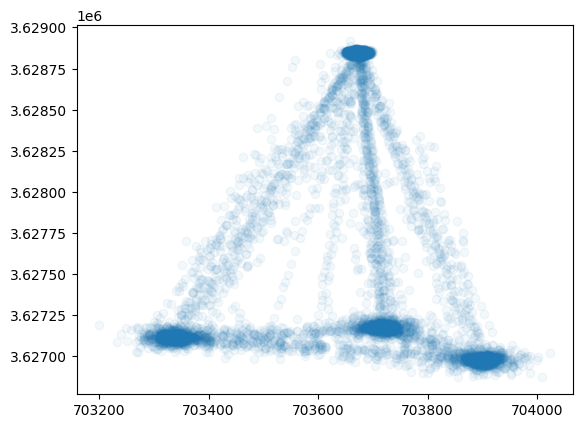

In [64]:
plt.scatter(df["x"], df["y"], alpha=0.05)
plt.show()